In [ ]:
#!pip install arch

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_goldfeldquandt, het_white
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
start = '2000-01-01'
end = '2024-01-01'

In [3]:
xlu =\
(
    yf.download('XLU',
                start,
                end)
)

[*********************100%%**********************]  1 of 1 completed


In [5]:
log_ret =\
(
    np
    .log(xlu['Adj Close'] 
         / xlu['Adj Close'].shift(1))
    .dropna()
)

In [6]:
log_returns =\
(
    pd
    .Series(log_ret)
)

In [7]:
X = sm.add_constant(np.arange(len(log_returns)))  # Shape: (n_samples, 2)
y = log_returns.values  # Dependent variable
ols_model = sm.OLS(y, X).fit()
residuals = ols_model.resid

In [8]:
gq_test = het_goldfeldquandt(y, X)
gq_pvalue = gq_test[1]
print(f"Goldfeld-Quandt test p-value: {gq_pvalue}")

Goldfeld-Quandt test p-value: 0.9999999999999999


In [9]:
white_test = het_white(residuals, X)
white_pvalue = white_test[1]
print(f"White test p-value: {white_pvalue}")

White test p-value: 0.00020361211372130382


In [10]:
# Decision based on p-values
if gq_pvalue < 0.05 or white_pvalue < 0.05:
    print("Evidence of heteroskedasticity detected.")
else:
    print("No evidence of heteroskedasticity detected.")

# Proceed with transformation if necessary (already using log returns)

Evidence of heteroskedasticity detected.


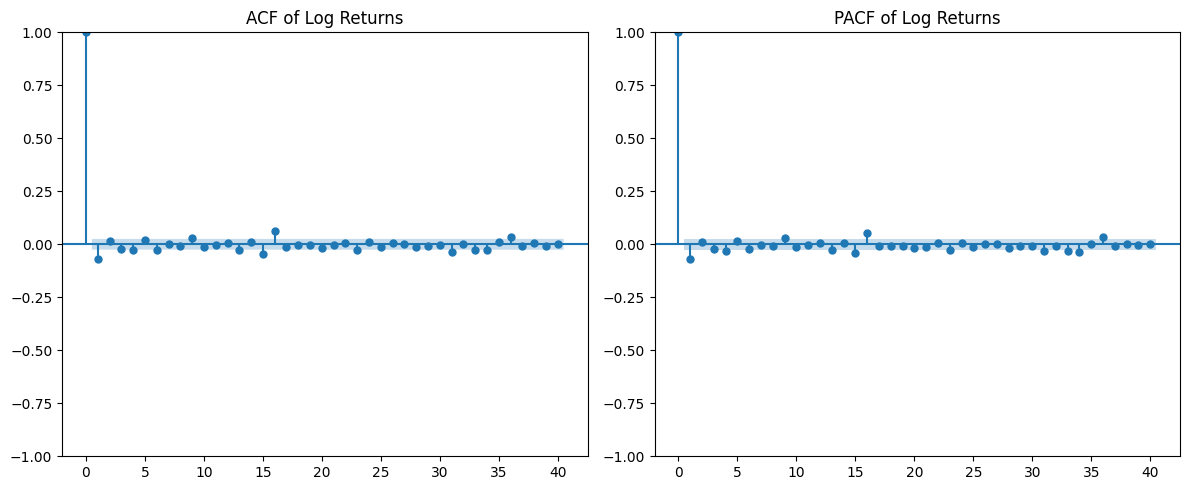

In [11]:
# ACF and PACF Plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(log_returns, ax=plt.gca(), lags=40)
plt.title('ACF of Log Returns')

plt.subplot(1, 2, 2)
plot_pacf(log_returns, ax=plt.gca(), lags=40, method='ywm')
plt.title('PACF of Log Returns')

plt.tight_layout()
plt.show()

In [12]:
rolling_window = 5
predictions = []
model_fits = []
residuals_garch = []

for i in range(rolling_window, len(log_returns)):
    model =\
    (
        arch_model(log_returns[i - rolling_window:i],
                   mean='Zero',
                   vol='FIGARCH',
                   p=1,
                   q=1)
    )
    
    model_fit =\
    (
        model
        .fit(disp='off')
    )
    
    forecast =\
    (
        model_fit
        .forecast(horizon=1)
    )
    
    date =\
    (
        log_returns
        .index[i]
    )
    
    prediction =\
    (
        forecast
        .variance
        .values[-1][0]
    )
    
    predictions\
        .append((date, prediction))
    
    model_fits\
        .append(model_fit)
    
    residuals_garch\
        .extend(model_fit.resid)

residuals_garch = np.array(residuals_garch)

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003286. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001415. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.383e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 6.458e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001849. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.975e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.611e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 5.137e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0002239. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0002326. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

...

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 6.26e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.933e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinr

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.374e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.764e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001322. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001326. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 8.669e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.651e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 5.257e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambinramli/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.326e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/Users/nasruddinislambin

In [13]:
predictions_df =\
(
    pd
    .DataFrame(predictions,
               columns=['Date', 'Predicted'])
)

predictions_df.set_index('Date', inplace=True)

In [14]:
predicted_volatility =\
(
    np
    .sqrt(predictions_df)
)

In [15]:
actual_returns = log_returns[rolling_window:]

In [16]:
common_index = predicted_volatility.index.intersection(actual_returns.index)
predicted_volatility_common = predicted_volatility.loc[common_index]
actual_returns_common = actual_returns.loc[common_index]

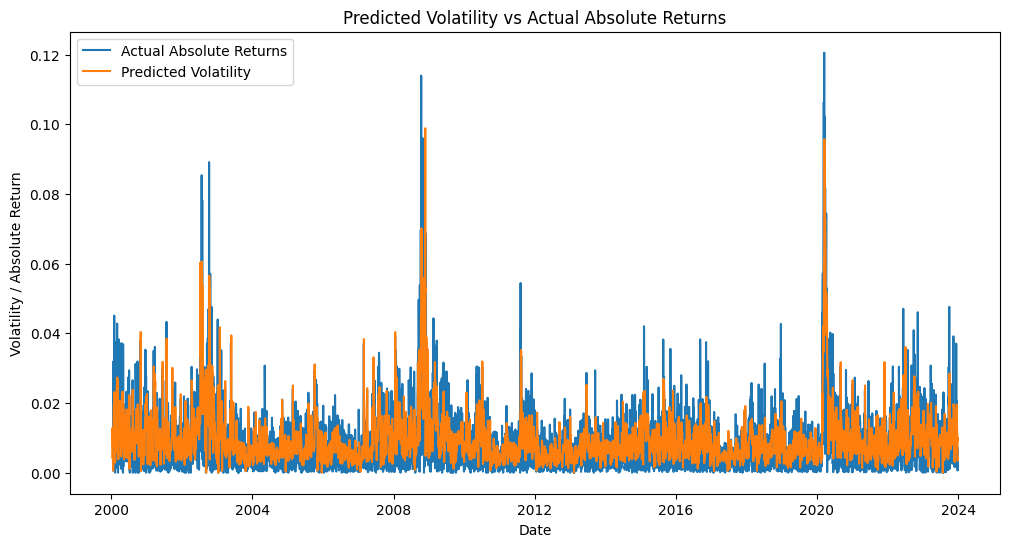

In [19]:
# Plot the predicted volatility
plt.figure(figsize=(12, 6))
plt.plot(actual_returns_common.index,
         np.abs(actual_returns_common),
         label='Actual Absolute Returns')

plt.plot(predicted_volatility_common.index,
         predicted_volatility_common['Predicted'], 
         label='Predicted Volatility')

plt.title('Predicted Volatility vs Actual Absolute Returns')
plt.xlabel('Date')
plt.ylabel('Volatility / Absolute Return')
plt.legend()
plt.show()

In [20]:
# Evaluate Forecast Performance
def smape(actual, forecast):
    return 100/len(actual) * np.sum(2 * np.abs(forecast - actual) / (np.abs(actual) + np.abs(forecast)))

roll_smape = smape(actual_returns, predicted_volatility['Predicted'])
rmse_roll = np.sqrt(np.mean((actual_returns.values - predicted_volatility['Predicted']) ** 2))

print(f"sMAPE: {roll_smape}")
print(f"RMSE: {rmse_roll}")

sMAPE: 131.06611923094593
RMSE: 0.017296663454060574


In [22]:
max_lag = min(10, len(residuals_garch) - 1)

ljung_box_result =\
(
    acorr_ljungbox(residuals_garch,
                   lags=max_lag,
                   return_df=False)
)

In [23]:
ljung_box_result

,lb_stat,lb_pvalue
1,107.658695,3.192880e-25
2,114.343619,1.481149e-25
3,190.472609,4.825221e-41
4,19214.770606,0.000000e+00
5,19358.926666,0.000000e+00
6,19365.572475,0.000000e+00
7,19415.951043,0.000000e+00
8,29868.181461,0.000000e+00
9,29946.922712,0.000000e+00
10,29953.599570,0.000000e+00


In [24]:
if ljung_box_result['lb_pvalue'].values[-1] < 0.05:
    print("Residuals are autocorrelated.")
else:
    print("No autocorrelation detected in residuals.")

Residuals are autocorrelated.


In [25]:
# predictions_df\
#     .to_csv('XLU_figarch_Nas.csv',
#             index = True)